In [1]:
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt


def IngMat(msg="Ingrese la matriz cuadrada: "):#solicitamos una matriz (lista de listas y la convertimos a SymPy)
    while True:
        try:
            ent= input(msg)
            lst= ast.literal_eval(ent)
            if not isinstance(lst, list) or not all(isinstance(fila, list) for fila in lst):
                raise ValueError("Debe ser una lista de listas (matriz).")
            mat= sp.Matrix(lst)
            return mat
        except Exception as e:
            print(f"Error: {e}. Intente de nuevo.")

def IngVec(msg="Ingrese el vector: "):#solicitamos un vector (lista y la pasamos a SymPy)
    while True:
        try:
            ent= input(msg)
            lst= ast.literal_eval(ent)
            if not isinstance(lst, list):
                raise ValueError("Debe ser una lista.")
            v= sp.Matrix(lst)
            return v
        except Exception as e:
            print(f"Error: {e}. Intente de nuevo.")

def MulVecInt():#multiplicacion vector por matriz
    print("Multiplicación matriz-vector")
    A= IngMat("Ingrese la matriz cuadrada (ej. [[0.7,0.3],[0.2,0.8]]): ")
    if A.rows != A.cols:
        print("Error: La matriz debe ser cuadrada.")
        return
    v= IngVec(f"Ingrese el vector de tamaño {A.rows} (ej. [0.5,0.5]): ")
    if A.cols != v.rows:
        print(f"Error: Dimensiones incompatibles: matriz {A.rows}x{A.cols}, vector {v.rows}x1.")
        return
    print("\nMatriz A:")
    sp.pprint(A)
    print("Vector v:")
    sp.pprint(v)
    print("\nPaso 1: Verificamos dimensiones: matriz cuadrada, vector columna de igual tamaño -> multiplicable")
    print("Paso 2: Calculamos cada componente:")
    res= sp.zeros(A.rows, 1)
    for i in range(A.rows):
        s= 0
        terms= []
        for j in range(A.cols):
            prod= A[i,j]*v[j]
            s+= prod
            terms.append(f"{A[i,j]}*{v[j]}")
        print(f"  (A*v)[{i}] = " + " + ".join(terms) + f" = {s}")
        res[i]= s
    print("\nResultado final (nuevo vector de estado):")
    sp.pprint(res)
    print()

def PotInt():#elevamos a la potencia n una matriz
    print("Potencia de matriz")
    A= IngMat("Ingrese la matriz cuadrada: ")
    if A.rows != A.cols:
        print("La matriz no es cuadrada. No se puede calcular potencia.")
        return
    try:
        n= int(input("Ingrese el exponente (entero no negativo): "))
        if n<0:
            print("El exponente debe ser no negativo.")
            return
    except:
        print("Debe ingresar un número entero.")
        return
    print("\nMatriz A:")
    sp.pprint(A)
    print(f"Calcularemos A^{n} mediante multiplicaciones sucesivas:")
    if n==0:
        print("A^0 = I (matriz identidad)")
        res=sp.eye(A.rows)
    else:
        res=A
        for k in range(2, n+1):
            print(f"Paso {k-1}:A^{k-1}*A =")
            res=res*A
            sp.pprint(res)
    print(f"\nResultado final A^{n} =")
    sp.pprint(res)
    print()

def SisInt():#resolvemos un sistema lineal del tipo A*x=b
    print("Resolución de sistema lineal")
    A= IngMat("Ingrese la matriz de coeficientes (cuadrada): ")
    if A.rows != A.cols:
        print("La matriz debe ser cuadrada.")
        return
    b= IngVec(f"Ingrese el vector de términos independientes de tamaño {A.rows}: ")
    if A.rows != b.rows:
        print(f"Error: Número de filas de la matriz ({A.rows}) no coincide con longitud del vector ({b.rows}).")
        return
    print("\nMatriz A:")
    sp.pprint(A)
    print("Vector b:")
    sp.pprint(b)
    print("\nPaso 1: Formamos la matriz aumentada [A | b]")
    Aug = A.row_join(b)
    sp.pprint(Aug)
    print("Paso 2: Aplicamos eliminación de Gauss (usamos solve() de SymPy)")
    try:
        x = A.solve(b)
        print("Solución x =")
        sp.pprint(x)
        print("Verificación: A * x =")
        sp.pprint(A * x)
    except Exception as e:
        print(f"No se pudo resolver: {e}")

def EigenInt():#calculamos vlaores y vectores propios
    print("Valores y vectores propios")
    A= IngMat("Ingrese la matriz cuadrada: ")
    if A.rows != A.cols:
        print("La matriz debe ser cuadrada.")
        return
    print("\nMatriz A:")
    sp.pprint(A)
    print("\nPaso 1: Calculamos el polinomio característico: det(A - λI) = 0")
    lam= sp.symbols('lambda')
    charpoly = A.charpoly(lam)
    print("  Polinomio:", charpoly.as_expr())
    print("Paso 2: Resolvemos para λ (valores propios):")
    evals= A.eigenvals()
    print("  Valores propios:", evals)
    print("Paso 3: Para cada valor propio, encontramos los vectores propios resolviendo (A - λI) v = 0")
    eig= A.eigenvects()
    print("Resultado completo:")
    for val, mult, vectores in eig:
        print(f"Valor propio: {val}, multiplicidad: {mult}")
        for v in vectores:
            print("Vector propio:")
            sp.pprint(v)
    print()

def DibTrans():#dibujamos un diagrama en base a la matriz
    print("\nDiagrama de transición")
    A= IngMat("Ingrese la matriz cuadrada (transición o adyacencia): ")
    if A.rows != A.cols:
        print("La matriz debe ser cuadrada.")
        return
    mat= A.tolist()  # convertir a lista
    n= len(mat)
    
    op= input("¿Desea nombrar los nodos? (s/n): ").lower()
    if op=='s':
        nds=[]
        for i in range(n):
            nombre= input(f"Nombre del nodo {i}: ")
            nds.append(nombre)
    else:
        nds= list(range(n))
    
    print("\nPaso 1: Creamos un grafo dirigido vacío.")
    G= nx.DiGraph()
    G.add_nodes_from(nds)
    print(f"  Nodos añadidos: {nds}")
    
    print("Paso 2: Añadimos aristas para cada entrada no nula de la matriz:")
    cnt= 0
    for i in range(n):
        for j in range(n):
            w= mat[i][j]
            try:
                wnum= float(w)
                if abs(wnum) < 1e-10:
                    continue
            except (TypeError, ValueError):
                # Si es simbólico, asumimos que no es cero
                pass
            G.add_edge(nds[i], nds[j], weight=w)
            print(f"  Arista de {nds[i]} a {nds[j]} con peso {w}")
            cnt += 1
    print(f"  Total de aristas añadidas: {cnt}")
    
    print("Paso 3: Dibujamos el grafo con las posiciones calculadas por spring_layout.")
    pos = nx.spring_layout(G)
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
    nx.draw_networkx_labels(G, pos, font_size=12, font_color='black')
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray', width=2)
    
    mostrar= input("¿Mostrar pesos en las aristas? (s/n): ").lower() == 's'
    if mostrar:
        elabs={}
        for u,v,d in G.edges(data=True):
            w=d['weight']
            if isinstance(w, (float, int)):
                lab= f"{w:.2f}"
            else:
                lab= str(w)
            elabs[(u,v)] = lab
        nx.draw_networkx_edge_labels(G, pos, edge_labels=elabs, font_size=10)
        print("  Se muestran los pesos en las aristas.")
    
    plt.title("Diagrama de transición")
    plt.axis('off')
    plt.show()
    print()
    
def EjeTab():

    from sympy import Rational, Matrix, symbols, solve, N
    import ast
    
    print("\n--- Ejemplo: Tablero (naranja,azul,verde,rojo) ---")
    print("Matriz de transición P (filas: actual, columnas: sig):")
    
    #Matriz P con fracciones exactas
    P = Matrix([[Rational(1,4), Rational(1,2), Rational(1,4), 0],
        [0, Rational(1,4), Rational(1,2), Rational(1,4)],
        [Rational(1,4), 0, Rational(1,4), Rational(1,2)],
        [Rational(1,2), Rational(1,4), 0, Rational(1,4)]])
    sp.pprint(P)
    print("(doble estocástica: filas y columnas suman 1)")
    
    #Pedimos el vector inicial [X0,Y0,Z0,t0]
    print("\nVector inicial (lista 4 nums, ej. [0,0,0,1]):")
    while True:
        try:
            ent = input("v0 = ")
            lst = ast.literal_eval(ent)
            if not isinstance(lst, list) or len(lst) != 4:
                raise ValueError("Se necesita lista de 4 elementos.")
            v0 = Matrix([Rational(x) for x in lst])
            break
        except Exception as e:
            print(f"Error: {e}. Intente otra vez.")
    
    # Opciones de simulación
    print("\nOpciones:")
    print("a) Iterar n pasos")
    print("b) Distribución estacionaria (analítica)")
    print("c) Iterar hasta convergencia")
    opc = input("Elija una opcion ").strip().lower()
    
    if opc=='a':
        try:
            n=int(input("Número de pasos: "))
            if n<0: raise ValueError
        except:
            print("Número inválido.")
            return
        print("\nEvolución:")
        v=v0
        print(f"paso 0: {v.T}  suma={sum(v)}")
        for k in range(1, n+1):
            v=P*v
            print(f"paso {k}: {v.T}  suma={sum(v)}")
        print(f"\nResultado final:")
        sp.pprint(v)
    
    elif opc == 'b':
        print("\nDistribución estacionaria π tal que πP=π, suma=1.")
        # Variables simbólicas p0..p3
        p = symbols('p0 p1 p2 p3')
        ecs = []
        # Ecuaciones πP = π  =>  π (P - I) = 0
        for i in range(4):
            ec = 0
            for j in range(4):
                ec+=p[j]*(P[j,i]-(1 if i==j else 0))
            ecs.append(ec)
        ecs.append(p[0]+p[1]+p[2]+p[3]-1)  # suma 1
        sol=solve(ecs, p)
        pi=Matrix([sol[pi] for pi in p])
        print("π =")
        sp.pprint(pi)
        print("\nVerificación πP:")
        sp.pprint(pi.T * P)
    
    elif opc == 'c':
        print("\nIterando hasta convergencia:")
        v=v0
        paso=0
        # Inicializamos dif como un número grande (usamos float para la comparación)
        dif = float('inf')
        tol = 1e-10
        maxp = 10000
        while dif > tol and paso < maxp:
            vn = P * v
            # Calculamos la máxima diferencia absoluta (sigue siendo Rational)
            dif_raw = max(abs(vn[i] - v[i]) for i in range(4))
            # Convertimos a float solo para la comparación (ya lo estábamos haciendo)
            dif = float(dif_raw)  # necesario para la condición del while
            v = vn
            paso += 1
            if paso % 10 == 0 or paso < 5:
                # Usamos N() para mostrar el valor con formato científico sin modificar el objeto
                print(f"paso {paso}: {v.T}  dif={N(dif_raw):.2e}")
        print(f"\nConvergido en {paso} pasos.")
        print("Distribución límite:")
        sp.pprint(v)
        print("Teórica: [1/4, 1/4, 1/4, 1/4]")
    
        import matplotlib.pyplot as plt
        nodos = ['Naranja', 'Azul', 'Verde', 'Rojo']
        G = nx.DiGraph()
        G.add_nodes_from(nodos)
        for i in range(4):
            for j in range(4):
                w = P[i,j]
                if w != 0:
                    G.add_edge(nodos[i], nodos[j], weight=float(w))
        pos = nx.spring_layout(G)
        nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
        nx.draw_networkx_labels(G, pos, font_size=12)
        nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray')
        etiq = {(u,v): f"{d['weight']:.2f}" for u,v,d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=etiq, font_size=10)
        plt.title("Transición del tablero")
        plt.axis('off')
        plt.show()
    
def encabezados():
    print("CALCULADORA DE MODELOS ESTOCASTICOS")
    print("1.-Multiplicacion matriz por vector")
    print("2.-Potencia de matriz")
    print("3.-Resolver sistema lineal A*x=b")
    print("4.-Valores y vectores propios")
    print("5.-Dibujar diagrama de transición")
    print("6.- Ejemplo del tablero")
    print("0.-Salir")
    
def menu():
    while True:
        encabezados()
        op=input("Seleccione una opción: ").strip()
        if op=='1':
            MulVecInt()
        elif op=='2':
            PotInt()
        elif op=='3':
            SisInt()
        elif op=='4':
            EigenInt()
        elif op=='5':
            DibTrans()
        elif op=='6':
            EjeTab()
        elif op=='0':
            print("Adios...")
            break
        else:
            print("Opción no valida")
        


CALCULADORA DE MODELOS ESTOCASTICOS
1.-Multiplicacion matriz por vector
2.-Potencia de matriz
3.-Resolver sistema lineal A*x=b
4.-Valores y vectores propios
5.-Dibujar diagrama de transición
6.- Ejemplo del tablero
0.-Salir


Seleccione una opción:  6



--- Ejemplo: Tablero (naranja,azul,verde,rojo) ---
Matriz de transición P (filas: actual, columnas: sig):
⎡1/4  1/2  1/4   0 ⎤
⎢                  ⎥
⎢ 0   1/4  1/2  1/4⎥
⎢                  ⎥
⎢1/4   0   1/4  1/2⎥
⎢                  ⎥
⎣1/2  1/4   0   1/4⎦
(doble estocástica: filas y columnas suman 1)

Vector inicial (lista 4 nums, ej. [0,0,0,1]):


v0 =  [0,0,0,1]



Opciones:
a) Iterar n pasos
b) Distribución estacionaria (analítica)
c) Iterar hasta convergencia


Elija a/b/c:  c



Iterando hasta convergencia (tol=1e-10, máx 10000 pasos):
paso 1: Matrix([[0, 1/4, 1/2, 1/4]])  dif=7.50e-1
paso 2: Matrix([[1/4, 3/8, 1/4, 1/8]])  dif=2.50e-1
paso 3: Matrix([[5/16, 1/4, 3/16, 1/4]])  dif=1.25e-1
paso 4: Matrix([[1/4, 7/32, 1/4, 9/32]])  dif=6.25e-2
paso 10: Matrix([[1/4, 513/2048, 1/4, 511/2048]])  dif=9.77e-4
paso 20: Matrix([[1/4, 524287/2097152, 1/4, 524289/2097152]])  dif=9.54e-7
paso 30: Matrix([[1/4, 536870913/2147483648, 1/4, 536870911/2147483648]])  dif=9.31e-10

Convergido en 34 pasos.
Distribución límite:
⎡    1/4    ⎤
⎢           ⎥
⎢8589934593 ⎥
⎢───────────⎥
⎢34359738368⎥
⎢           ⎥
⎢    1/4    ⎥
⎢           ⎥
⎢8589934591 ⎥
⎢───────────⎥
⎣34359738368⎦
Teórica: [1/4, 1/4, 1/4, 1/4]



¿Dibujar diagrama? (s/n):  S


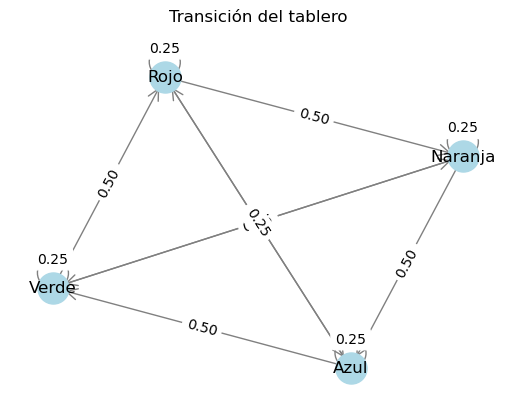


--- Fin EjeTab ---

CALCULADORA DE MODELOS ESTOCASTICOS
1.-Multiplicacion matriz por vector
2.-Potencia de matriz
3.-Resolver sistema lineal A*x=b
4.-Valores y vectores propios
5.-Dibujar diagrama de transición
6.- Ejemplo del tablero
0.-Salir


Seleccione una opción:  2



--- Potencia de matriz ---


Ingrese la matriz cuadrada:  3


Error: name 'ast' is not defined. Intente de nuevo.


In [ ]:
menu()